In [1]:
# Importing the necessary libraries (tools) for our model
import re
import pandas as pd                # Used to handle and process data (like Excel tables).
import matplotlib.pyplot as plt    # Used for drawing graphs and charts.
import numpy as np                 # Used for working with numbers and arrays.
import gzip                        # Used for handling compressed files (not directly used here).
from sklearn.ensemble import RandomForestClassifier  # Machine learning model (Random Forest).
from sklearn.model_selection import train_test_split # Tool to split data into training and testing sets.
from sklearn.metrics import classification_report    # Tool to measure model performance.
import seaborn as sns              # Used for advanced visualizations (nice graphs).
from statsmodels.stats.outliers_influence import variance_inflation_factor 
# VIF is used to check for multicollinearity (when two variables are very similar).

In [2]:
# Reading an Excel file containing the SWaT dataset.
# - 'header=[0,1]' means the file has two rows at the top that describe column names.
# - 'skiprows=1' means skip the first row of the file (since it's not useful).
df = pd.read_excel(r"C:\Users\manda\OneDrive\Desktop\DissertationModel\SWaT_dataset_Jul 19 v2.xlsx", header=[0,1], skiprows=1)

# The dataset has multi-level column names (like two headers). 
# This line merges them into a single name, separated by "_".
# Example: If column names are ("LIT101", "Value"), it becomes "LIT101_Value".
df.columns = ['_'.join([str(c1), str(c2)]).strip() for c1, c2 in df.columns]

In [3]:
#loading the dataframe
df

,GMT +0_timestamp,FIT 101_value,LIT 101_value,MV 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,...,LSH 601_value,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value
0,2019-07-20T04:30:00Z,0.000000,729.865800,1,3,2,1,142.527557,9.293002,198.077423,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
1,2019-07-20T04:30:01Z,0.000000,729.434000,1,3,2,1,142.527557,9.293002,198.385025,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
2,2019-07-20T04:30:02.004013Z,0.000000,729.120000,1,3,2,1,142.527557,9.293002,198.436300,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
3,2019-07-20T04:30:03.004013Z,0.000000,728.688200,1,3,2,1,142.527557,9.289157,198.667000,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
4,2019-07-20T04:30:04Z,0.000000,727.706900,1,3,2,1,142.527557,9.289157,198.897720,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,2019-07-20T08:39:55.001007Z,4.200429,491.169769,2,2,2,1,131.408615,9.319918,257.703156,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
14992,2019-07-20T08:39:56.0050048Z,4.253915,491.405273,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
14993,2019-07-20T08:39:57.0050048Z,4.303558,492.308100,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1
14994,2019-07-20T08:39:58.0050048Z,4.323736,492.465100,2,2,2,1,131.408615,9.316713,257.703156,...,Active,Active,Inactive,Inactive,Inactive,Active,2,1,1,1


In [4]:
#listing the data columns
df.columns

Index(['GMT +0_timestamp', 'FIT 101_value', 'LIT 101_value', 'MV 101_value',
       'P1_STATE_value', 'P101 Status_value', 'P102 Status_value',
       'AIT 201_value', 'AIT 202_value', 'AIT 203_value', 'FIT 201_value',
       'LS 201_value', 'LS 202_value', 'LSL 203_value', 'LSLL 203_value',
       'MV201_value', 'P2_STATE_value', 'P201 Status_value',
       'P202 Status_value', 'P203 Status_value', 'P204 Status_value',
       'P205 Status_value', 'P206 Status_value', 'P207 Status_value',
       'P208 Status_value', 'AIT 301_value', 'AIT 302_value', 'AIT 303_value',
       'DPIT 301_value', 'FIT 301_value', 'LIT 301_value', 'MV 301_value',
       'MV 302_value', 'MV 303_value', 'MV 304_value', 'P3_STATE_value',
       'P301 Status_value', 'P302 Status_value', 'AIT 401_value',
       'AIT 402_value', 'FIT 401_value', 'LIT 401_value', 'LS 401_value',
       'P4_STATE_value', 'P401 Status_value', 'P402 Status_value',
       'P403 Status_value', 'P404 Status_value', 'UV401_value',
       '

In [5]:
#checking null values
df['GMT +0_timestamp'].isnull().sum()

np.int64(0)

In [6]:
# ==== 2. Convert timestamp from GMT+0 to GMT+8 ====

# The dataset has a timestamp in GMT+0 (London/UTC time).
# We want to convert it to GMT+8 (like Singapore time, where the SWaT plant is).
df['timestamp'] = pd.to_datetime(df['GMT +0_timestamp'], format='ISO8601', utc=True)  
# Convert the text timestamp into a real "datetime" format, treating it as UTC.

df['timestamp'] = df['timestamp'] + pd.Timedelta(hours=8)  
# Add 8 hours to shift from GMT+0 → GMT+8.

df['timestamp'] = df['timestamp'].dt.tz_localize(None)  
# Remove the timezone info, so it's just a "clean" datetime column.

In [7]:
df['timestamp'].isnull().sum()

np.int64(0)

In [8]:
df

,GMT +0_timestamp,FIT 101_value,LIT 101_value,MV 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,...,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value,timestamp
0,2019-07-20T04:30:00Z,0.000000,729.865800,1,3,2,1,142.527557,9.293002,198.077423,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:00.000000000
1,2019-07-20T04:30:01Z,0.000000,729.434000,1,3,2,1,142.527557,9.293002,198.385025,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:01.000000000
2,2019-07-20T04:30:02.004013Z,0.000000,729.120000,1,3,2,1,142.527557,9.293002,198.436300,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:02.004013000
3,2019-07-20T04:30:03.004013Z,0.000000,728.688200,1,3,2,1,142.527557,9.289157,198.667000,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:03.004013000
4,2019-07-20T04:30:04Z,0.000000,727.706900,1,3,2,1,142.527557,9.289157,198.897720,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:04.000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,2019-07-20T08:39:55.001007Z,4.200429,491.169769,2,2,2,1,131.408615,9.319918,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:55.001007000
14992,2019-07-20T08:39:56.0050048Z,4.253915,491.405273,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:56.005004800
14993,2019-07-20T08:39:57.0050048Z,4.303558,492.308100,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:57.005004800
14994,2019-07-20T08:39:58.0050048Z,4.323736,492.465100,2,2,2,1,131.408615,9.316713,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:58.005004800


In [9]:
df

,GMT +0_timestamp,FIT 101_value,LIT 101_value,MV 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,...,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value,timestamp
0,2019-07-20T04:30:00Z,0.000000,729.865800,1,3,2,1,142.527557,9.293002,198.077423,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:00.000000000
1,2019-07-20T04:30:01Z,0.000000,729.434000,1,3,2,1,142.527557,9.293002,198.385025,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:01.000000000
2,2019-07-20T04:30:02.004013Z,0.000000,729.120000,1,3,2,1,142.527557,9.293002,198.436300,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:02.004013000
3,2019-07-20T04:30:03.004013Z,0.000000,728.688200,1,3,2,1,142.527557,9.289157,198.667000,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:03.004013000
4,2019-07-20T04:30:04Z,0.000000,727.706900,1,3,2,1,142.527557,9.289157,198.897720,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:04.000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,2019-07-20T08:39:55.001007Z,4.200429,491.169769,2,2,2,1,131.408615,9.319918,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:55.001007000
14992,2019-07-20T08:39:56.0050048Z,4.253915,491.405273,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:56.005004800
14993,2019-07-20T08:39:57.0050048Z,4.303558,492.308100,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:57.005004800
14994,2019-07-20T08:39:58.0050048Z,4.323736,492.465100,2,2,2,1,131.408615,9.316713,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:58.005004800


In [10]:
def find_timestamp_col(cols):
    # Check all column names and see if they contain words like "gmt", "timestamp", or "time".
    candidates = [c for c in cols if any(k in c.lower() for k in ("gmt", "timestamp", "time"))]
    
    if not candidates:
        # If no such column is found, just use the first column as fallback.
        return cols[0]
    
    return candidates[0]


# ------------------------------------------------
# Helper function to clean up "Active/Inactive" status values
# ------------------------------------------------

def parse_active_inactive(x):
    # If the value is empty/missing, keep it as NaN (Not a Number).
    if pd.isna(x):
        return np.nan
    
    s = str(x)  # Convert value into string (so we can search inside).
    
    # Case 1: If the word "Active" is present → return 1.
    if re.search(r"\bactive\b", s, flags=re.IGNORECASE):
        return 1
    
    # Case 2: If the word "Inactive" is present → return 0.
    if re.search(r"\binactive\b", s, flags=re.IGNORECASE):
        return 0
    
    # Case 3: Sometimes the status is hidden inside messy text like "Name': u'Inactive'".
    # This pattern tries to extract that.
    m = re.search(r"Name':\s*u?'?([A-Za-z_]+)'?", s)
    if m:
        val = m.group(1).lower()
        if val == "active":
            return 1
        if val == "inactive":
            return 0
    
    # Case 4: If none of the above, try to convert it into a number (e.g., 0 or 1).
    try:
        return float(s)
    except:
        # If conversion fails, return missing value.
        return np.nan

In [11]:
#checking the time stamp column:
ts_col = find_timestamp_col(df.columns.tolist())
print("Using timestamp column:", ts_col)

Using timestamp column: GMT +0_timestamp


In [12]:
df['timestamp'].isnull().sum()

np.int64(0)

In [13]:
df.columns

Index(['GMT +0_timestamp', 'FIT 101_value', 'LIT 101_value', 'MV 101_value',
       'P1_STATE_value', 'P101 Status_value', 'P102 Status_value',
       'AIT 201_value', 'AIT 202_value', 'AIT 203_value', 'FIT 201_value',
       'LS 201_value', 'LS 202_value', 'LSL 203_value', 'LSLL 203_value',
       'MV201_value', 'P2_STATE_value', 'P201 Status_value',
       'P202 Status_value', 'P203 Status_value', 'P204 Status_value',
       'P205 Status_value', 'P206 Status_value', 'P207 Status_value',
       'P208 Status_value', 'AIT 301_value', 'AIT 302_value', 'AIT 303_value',
       'DPIT 301_value', 'FIT 301_value', 'LIT 301_value', 'MV 301_value',
       'MV 302_value', 'MV 303_value', 'MV 304_value', 'P3_STATE_value',
       'P301 Status_value', 'P302 Status_value', 'AIT 401_value',
       'AIT 402_value', 'FIT 401_value', 'LIT 401_value', 'LS 401_value',
       'P4_STATE_value', 'P401 Status_value', 'P402 Status_value',
       'P403 Status_value', 'P404 Status_value', 'UV401_value',
       '

In [14]:
df

,GMT +0_timestamp,FIT 101_value,LIT 101_value,MV 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,...,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value,timestamp
0,2019-07-20T04:30:00Z,0.000000,729.865800,1,3,2,1,142.527557,9.293002,198.077423,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:00.000000000
1,2019-07-20T04:30:01Z,0.000000,729.434000,1,3,2,1,142.527557,9.293002,198.385025,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:01.000000000
2,2019-07-20T04:30:02.004013Z,0.000000,729.120000,1,3,2,1,142.527557,9.293002,198.436300,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:02.004013000
3,2019-07-20T04:30:03.004013Z,0.000000,728.688200,1,3,2,1,142.527557,9.289157,198.667000,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:03.004013000
4,2019-07-20T04:30:04Z,0.000000,727.706900,1,3,2,1,142.527557,9.289157,198.897720,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 12:30:04.000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,2019-07-20T08:39:55.001007Z,4.200429,491.169769,2,2,2,1,131.408615,9.319918,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:55.001007000
14992,2019-07-20T08:39:56.0050048Z,4.253915,491.405273,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:56.005004800
14993,2019-07-20T08:39:57.0050048Z,4.303558,492.308100,2,2,2,1,131.408615,9.317354,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:57.005004800
14994,2019-07-20T08:39:58.0050048Z,4.323736,492.465100,2,2,2,1,131.408615,9.316713,257.703156,...,Active,Inactive,Inactive,Inactive,Active,2,1,1,1,2019-07-20 16:39:58.005004800


In [15]:
df.columns

Index(['GMT +0_timestamp', 'FIT 101_value', 'LIT 101_value', 'MV 101_value',
       'P1_STATE_value', 'P101 Status_value', 'P102 Status_value',
       'AIT 201_value', 'AIT 202_value', 'AIT 203_value', 'FIT 201_value',
       'LS 201_value', 'LS 202_value', 'LSL 203_value', 'LSLL 203_value',
       'MV201_value', 'P2_STATE_value', 'P201 Status_value',
       'P202 Status_value', 'P203 Status_value', 'P204 Status_value',
       'P205 Status_value', 'P206 Status_value', 'P207 Status_value',
       'P208 Status_value', 'AIT 301_value', 'AIT 302_value', 'AIT 303_value',
       'DPIT 301_value', 'FIT 301_value', 'LIT 301_value', 'MV 301_value',
       'MV 302_value', 'MV 303_value', 'MV 304_value', 'P3_STATE_value',
       'P301 Status_value', 'P302 Status_value', 'AIT 401_value',
       'AIT 402_value', 'FIT 401_value', 'LIT 401_value', 'LS 401_value',
       'P4_STATE_value', 'P401 Status_value', 'P402 Status_value',
       'P403 Status_value', 'P404 Status_value', 'UV401_value',
       '

In [16]:
# Step 1: Check data types and first few values of important columns
print(df[['P101 Status_value', 'MV201_value', 'LIT 301_value', 'FIT 201_value']].dtypes)
print(df[['P101 Status_value', 'MV201_value', 'LIT 301_value', 'FIT 201_value']].head())

# This is just to quickly look at:
# - What type of data these columns are (numbers, text, etc.)
# - What the first few rows look like (to spot any weird values)

P101 Status_value      int64
MV201_value            int64
LIT 301_value        float64
FIT 201_value        float64
dtype: object
   P101 Status_value  MV201_value  LIT 301_value  FIT 201_value
0                  2            2     730.702100       2.335437
1                  2            2     730.902344       2.335437
2                  2            2     732.344300       2.335437
3                  2            2     732.704800       2.335437
4                  2            2     732.744800       2.335437


In [17]:
exclude = {ts_col, 'timestamp', 'attack'}  
# Exclude columns we don't want to use as features:
# - ts_col = original timestamp column
# - 'timestamp' = the cleaned time column
# - 'attack' = the target label (we want to predict this, not use it as input)

feature_cols = [c for c in df.columns if c not in exclude]  
print(f"Candidate feature columns count: {len(feature_cols)}")

# All other columns (except excluded ones) are potential features.

Candidate feature columns count: 77


In [18]:
X = pd.DataFrame(index=df.index)  
# Create a new DataFrame that will hold the cleaned features.

for col in feature_cols:   # loop through every feature column
    series = df[col]       # take the column from the dataset

    # Case 1: If column is already numeric (int/float) → just keep it as float
    if pd.api.types.is_numeric_dtype(series):
        X[col] = series.astype(float)
        continue

    # Case 2: Try to convert text into numbers
    num = pd.to_numeric(series, errors='coerce')
    if num.notna().sum() / len(num) > 0.8:  
        # If at least 80% of values are valid numbers → keep as numeric
        X[col] = num
        continue

    # Case 3: Try to parse Active/Inactive status into 1/0
    parsed = series.apply(parse_active_inactive)
    if parsed.notna().sum() / len(parsed) > 0.2:  
        # If at least 20% of values can be converted → use it
        X[col] = parsed
        continue

    # Case 4: If column has small number of categories (≤ 20 unique values)
    n_unique = series.nunique(dropna=True)
    if n_unique <= 20:
        # Convert categorical text into dummy variables (one-hot encoding).
        # Example: "OPEN", "CLOSED" → two separate columns: col_OPEN, col_CLOSED.
        dummies = pd.get_dummies(series.astype(str), prefix=col, dummy_na=False)
        X = pd.concat([X, dummies], axis=1)
    else:
        # Case 5: If column has too many categories (like IDs, long strings) → drop it.
        print(f"Dropping high-cardinality non-numeric column: {col} ({n_unique} unique)")

In [19]:
#Fill missing values by carrying last valid value forward, 
# and if still missing, carry the next valid value backward.
X = X.fillna(method='ffill').fillna(method='bfill')

# Double-check if any missing values are left
for c in X.columns:
    if X[c].isna().any():
        if pd.api.types.is_numeric_dtype(X[c]):
            # If numeric → fill with median of the column
            X[c] = X[c].fillna(X[c].median())
        else:
            # If not numeric → fill with 0
            X[c] = X[c].fillna(0)

C:\Users\manda\AppData\Local\Temp\ipykernel_13116\1853325157.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='ffill').fillna(method='bfill')


In [20]:
# Pick the columns we want to check for missing values
cols = ["P101 Status_value", "MV201_value", "LIT 301_value", "FIT 201_value"]


# Step 1: Count how many missing values (NaN) are in each column

print(df[cols].isna().sum())
# This shows, for each column, how many entries are blank or missing.

# Show the actual rows that have missing values

print(df[cols][df[cols].isna().any(axis=1)])
# This filters the data and prints only the rows where at least 
# one of these columns is missing.

P101 Status_value    0
MV201_value          0
LIT 301_value        0
FIT 201_value        0
dtype: int64
Empty DataFrame
Columns: [P101 Status_value, MV201_value, LIT 301_value, FIT 201_value]
Index: []


In [21]:
df.isnull().sum()

GMT +0_timestamp     0
FIT 101_value        0
LIT 101_value        0
MV 101_value         0
P1_STATE_value       0
                    ..
P6 STATE_value       0
P601 Status_value    0
P602 Status_value    0
P603 Status_value    0
timestamp            0
Length: 79, dtype: int64

In [22]:
df["LIT 301_value"].std()

92.16856565341723

In [23]:
cols = ["P101 Status_value", "MV201_value", "LIT 301_value", "FIT 201_value"]

# Count null values in each column
print(df[cols].isna().sum())

# Show rows that contain nulls (optional)
print(df[cols][df[cols].isna().any(axis=1)])

P101 Status_value    0
MV201_value          0
LIT 301_value        0
FIT 201_value        0
dtype: int64
Empty DataFrame
Columns: [P101 Status_value, MV201_value, LIT 301_value, FIT 201_value]
Index: []


In [24]:
df.columns

Index(['GMT +0_timestamp', 'FIT 101_value', 'LIT 101_value', 'MV 101_value',
       'P1_STATE_value', 'P101 Status_value', 'P102 Status_value',
       'AIT 201_value', 'AIT 202_value', 'AIT 203_value', 'FIT 201_value',
       'LS 201_value', 'LS 202_value', 'LSL 203_value', 'LSLL 203_value',
       'MV201_value', 'P2_STATE_value', 'P201 Status_value',
       'P202 Status_value', 'P203 Status_value', 'P204 Status_value',
       'P205 Status_value', 'P206 Status_value', 'P207 Status_value',
       'P208 Status_value', 'AIT 301_value', 'AIT 302_value', 'AIT 303_value',
       'DPIT 301_value', 'FIT 301_value', 'LIT 301_value', 'MV 301_value',
       'MV 302_value', 'MV 303_value', 'MV 304_value', 'P3_STATE_value',
       'P301 Status_value', 'P302 Status_value', 'AIT 401_value',
       'AIT 402_value', 'FIT 401_value', 'LIT 401_value', 'LS 401_value',
       'P4_STATE_value', 'P401 Status_value', 'P402 Status_value',
       'P403 Status_value', 'P404 Status_value', 'UV401_value',
       '

In [25]:
#finding unique value:
df["P101 Status_value"].unique()

array([2, 1])

In [26]:
# 1) Pump anomaly rule

df["pump_anomaly"] = (
    (df["P101 Status_value"] == 2)   # Pump is ON (status = 2)
    & (df["LIT 101_value"].abs() < 0.01)  # But the water level sensor shows no change
).astype(int)
# If pump is ON but level is not changing → mark as anomaly (1). Else → 0.



# 2) Valve anomaly rule

df["valve_anomaly"] = (
    (df["MV 101_value"] == 1)    # Valve is OPEN
    & (df["FIT 101_value"] < 0.01)  # But the flow sensor shows no water flow
).astype(int)
# If valve is OPEN but no water flow → anomaly (1). Else → 0.



# 3) Sensor freeze rule

df["sensor_freeze"] = (
    # Case A: Level sensor (LIT 101) is not changing
    # while the pump status suddenly changes (toggle ON/OFF).
    ((df["LIT 101_value"].diff().abs() < 1e-3) 
     & (df["P101 Status_value"].diff().abs() == 2))
    
    |
    
    # Case B: Flow sensor (FIT 201) is not changing
    # while the valve status suddenly changes (toggle OPEN/CLOSE).
    ((df["FIT 201_value"].diff().abs() < 1e-3) 
     & (df["MV 101_value"].diff().abs() == 1))
).astype(int)
# If a sensor reading stays "frozen" even though actuators are toggling → anomaly (1).



# 4) Combine all anomaly rules into one column

df["logic_anomaly"] = (
    df[["pump_anomaly", "valve_anomaly", "sensor_freeze"]].max(axis=1)
)
# Take the maximum across all three anomaly types:
# If ANY of pump/valve/sensor rules is 1 → mark logic_anomaly = 1.
# If none are triggered → logic_anomaly = 0.


In [27]:
df

,GMT +0_timestamp,FIT 101_value,LIT 101_value,MV 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,...,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value,timestamp,pump_anomaly,valve_anomaly,sensor_freeze,logic_anomaly
0,2019-07-20T04:30:00Z,0.000000,729.865800,1,3,2,1,142.527557,9.293002,198.077423,...,Active,2,1,1,1,2019-07-20 12:30:00.000000000,0,1,0,1
1,2019-07-20T04:30:01Z,0.000000,729.434000,1,3,2,1,142.527557,9.293002,198.385025,...,Active,2,1,1,1,2019-07-20 12:30:01.000000000,0,1,0,1
2,2019-07-20T04:30:02.004013Z,0.000000,729.120000,1,3,2,1,142.527557,9.293002,198.436300,...,Active,2,1,1,1,2019-07-20 12:30:02.004013000,0,1,0,1
3,2019-07-20T04:30:03.004013Z,0.000000,728.688200,1,3,2,1,142.527557,9.289157,198.667000,...,Active,2,1,1,1,2019-07-20 12:30:03.004013000,0,1,0,1
4,2019-07-20T04:30:04Z,0.000000,727.706900,1,3,2,1,142.527557,9.289157,198.897720,...,Active,2,1,1,1,2019-07-20 12:30:04.000000000,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,2019-07-20T08:39:55.001007Z,4.200429,491.169769,2,2,2,1,131.408615,9.319918,257.703156,...,Active,2,1,1,1,2019-07-20 16:39:55.001007000,0,0,0,0
14992,2019-07-20T08:39:56.0050048Z,4.253915,491.405273,2,2,2,1,131.408615,9.317354,257.703156,...,Active,2,1,1,1,2019-07-20 16:39:56.005004800,0,0,0,0
14993,2019-07-20T08:39:57.0050048Z,4.303558,492.308100,2,2,2,1,131.408615,9.317354,257.703156,...,Active,2,1,1,1,2019-07-20 16:39:57.005004800,0,0,0,0
14994,2019-07-20T08:39:58.0050048Z,4.323736,492.465100,2,2,2,1,131.408615,9.316713,257.703156,...,Active,2,1,1,1,2019-07-20 16:39:58.005004800,0,0,0,0


In [28]:
#checking the value counts
# 1 :anomaly
# 0 :no anomaly
df['logic_anomaly'].value_counts()

logic_anomaly
1    12365
0     2631
Name: count, dtype: int64

In [29]:
# Final feature list
final_features = X.columns.tolist()
print("Final numeric features used:", len(final_features))

Final numeric features used: 77


In [30]:
if len(final_features) == 0:
    raise SystemExit("No features remained after preprocessing. Inspect the original dataframe columns.")

In [31]:
y = df['logic_anomaly'].astype(int)
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=50, stratify=y
)
#stratify=y = keeps the same ratio of normal vs anomaly in both train/test

In [32]:
from sklearn.feature_selection import RFE

# Use Random Forest as the base model
rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=200, random_state=42),
    n_features_to_select=10   # keep only the 10 best features
)

rfe.fit(X_train, y_train)

selected_features_rfe = X_train.columns[rfe.support_].tolist()
print("\nRFE Selected Features:", selected_features_rfe)

# RFE = repeatedly removes the least important features until only
#  the top 10 most useful ones are left.


RFE Selected Features: ['FIT 101_value', 'LIT 101_value', 'MV 101_value', 'AIT 202_value', 'AIT 203_value', 'AIT 302_value', 'DPIT 301_value', 'LIT 301_value', 'MV 302_value', 'P3_STATE_value']


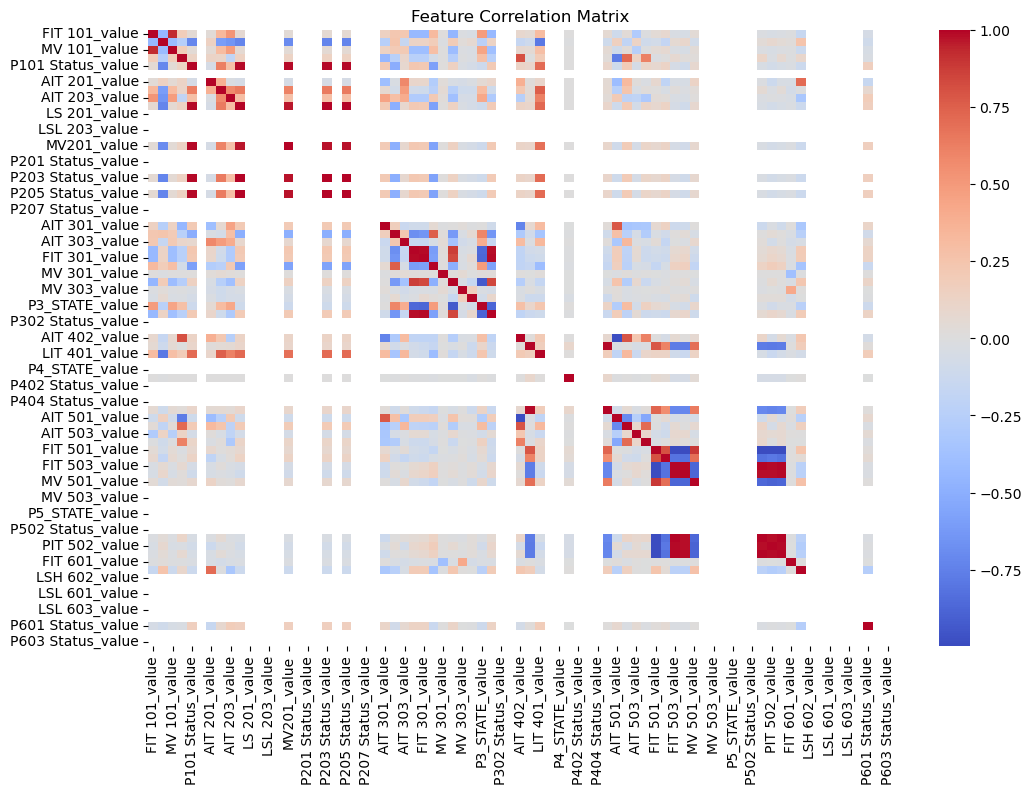

C:\Users\manda\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\manda\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\manda\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF Scores:
               Feature          VIF
18  P203 Status_value          inf
20  P205 Status_value          inf
63      PIT 501_value  2901.169625
65      PIT 503_value  2072.336660
52      FIT 501_value   481.687187
..                ...          ...
37      AIT 401_value          NaN
41       LS 401_value          NaN
69      LSH 603_value          NaN
70      LSL 601_value          NaN
71      LSL 602_value          NaN

[77 rows x 2 columns]


In [33]:
plt.figure(figsize=(12,8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

# Shows which features move together.
# High correlation means some features carry duplicate information


# Step 4: VIF (Variance Inflation Factor)

def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_df.values, i)
        for i in range(len(X_df.columns))
    ]
    return vif_data

vif_df = calculate_vif(X)
print("\nVIF Scores:\n", vif_df.sort_values(by="VIF", ascending=False))

# VIF tells us if a feature is redundant due to multicollinearity.
# High VIF (>10) = strongly correlated with others, so not useful.

In [34]:
threshold = 0.9
corr_pairs = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            corr_pairs.add(colname)

print("\nFeatures to drop due to high correlation (>0.9):", corr_pairs)

X_reduced = X.drop(columns=list(corr_pairs))
print("Reduced feature count:", X_reduced.shape[1])

# This removes duplicate information so the model doesn’t get confused.


Features to drop due to high correlation (>0.9): {'P301 Status_value', 'FIT 301_value', 'P205 Status_value', 'FIT 201_value', 'PIT 502_value', 'UV401_value', 'FIT 503_value', 'PIT 503_value', 'PIT 501_value', 'MV 101_value', 'AIT 501_value', 'P203 Status_value', 'MV201_value', 'FIT 504_value', 'P3_STATE_value'}
Reduced feature count: 62


                   FIT 101_value  LIT 101_value  MV 101_value  P1_STATE_value  \
FIT 101_value           1.000000      -0.444247      0.925853        0.189449   
LIT 101_value          -0.444247       1.000000     -0.413625       -0.261373   
MV 101_value            0.925853      -0.413625      1.000000        0.187424   
P1_STATE_value          0.189449      -0.261373      0.187424        1.000000   
P101 Status_value       0.052807      -0.714992      0.047949        0.133112   
...                          ...            ...           ...             ...   
P603 Status_value            NaN            NaN           NaN             NaN   
pump_anomaly                 NaN            NaN           NaN             NaN   
valve_anomaly          -0.980565       0.455273     -0.879274       -0.188833   
sensor_freeze           0.022589      -0.013896     -0.038304        0.005044   
logic_anomaly          -0.980429       0.454991     -0.882922       -0.188762   

                   P101 Sta

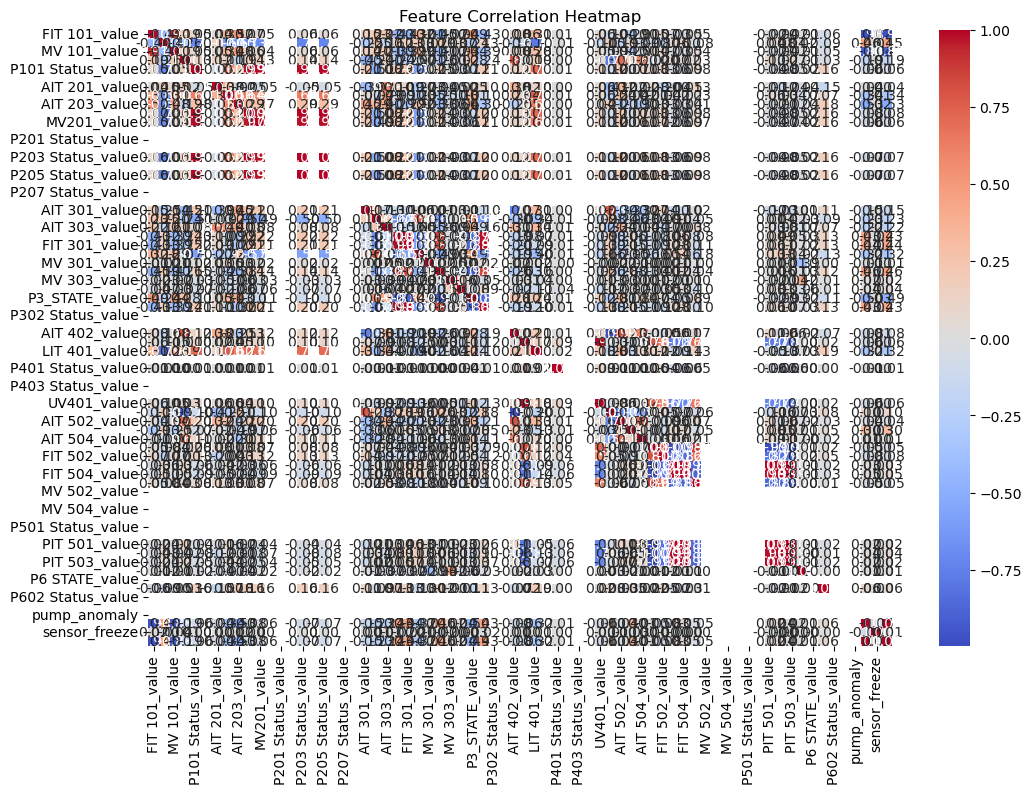

In [35]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()

# This final heatmap lets you visually inspect all numeric features 
# to confirm which ones are strongly related.

Reduced feature count: 62

Top features by importance after correlation filtering:
           feature  importance
0    FIT 101_value    0.270221
22  DPIT 301_value    0.125043
1    LIT 101_value    0.118682
7    AIT 203_value    0.091624
6    AIT 202_value    0.060343
25    MV 302_value    0.060265
20   AIT 302_value    0.048976
23   LIT 301_value    0.037690
32   LIT 401_value    0.033780
30   AIT 402_value    0.026406
39   AIT 502_value    0.024372
19   AIT 301_value    0.023890
21   AIT 303_value    0.013787
5    AIT 201_value    0.013757
40   AIT 503_value    0.012642
41   AIT 504_value    0.008803
51   FIT 601_value    0.007222
2   P1_STATE_value    0.004942
43   FIT 502_value    0.004461
42   FIT 501_value    0.003737


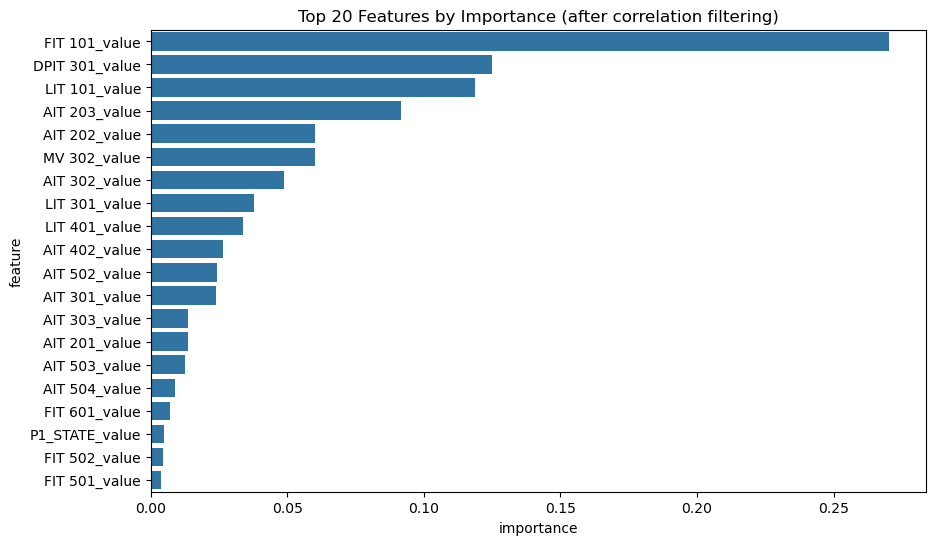

In [36]:
X_reduced = X.drop(columns=list(corr_pairs))
print("Reduced feature count:", X_reduced.shape[1])
# We remove features that were highly correlated earlier.
# This avoids duplicate information and makes the model simpler.



# Step 2: Train Random Forest Model
model = RandomForestClassifier(
    n_estimators=200,        # number of trees in the forest
    random_state=66,         # random seed for reproducibility
    class_weight='balanced'  # handle imbalance between normal (0) and anomaly (1)
)
model.fit(X_reduced, y)
# Train a Random Forest on the reduced dataset to predict logic anomalies.



# Step 3: Check feature importance
feature_importances = pd.DataFrame({
    'feature': X_reduced.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop features by importance after correlation filtering:")
print(feature_importances.head(20))
# Random Forest tells us how much each feature contributes to predictions.
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(20), x='importance', y='feature')
plt.title("Top 20 Features by Importance (after correlation filtering)")
plt.show()
# Bar chart to visualize which features the model thinks are most important.

In [37]:
a=print(feature_importances.head(10))
a=pd.DataFrame(a)

           feature  importance
0    FIT 101_value    0.270221
22  DPIT 301_value    0.125043
1    LIT 101_value    0.118682
7    AIT 203_value    0.091624
6    AIT 202_value    0.060343
25    MV 302_value    0.060265
20   AIT 302_value    0.048976
23   LIT 301_value    0.037690
32   LIT 401_value    0.033780
30   AIT 402_value    0.026406


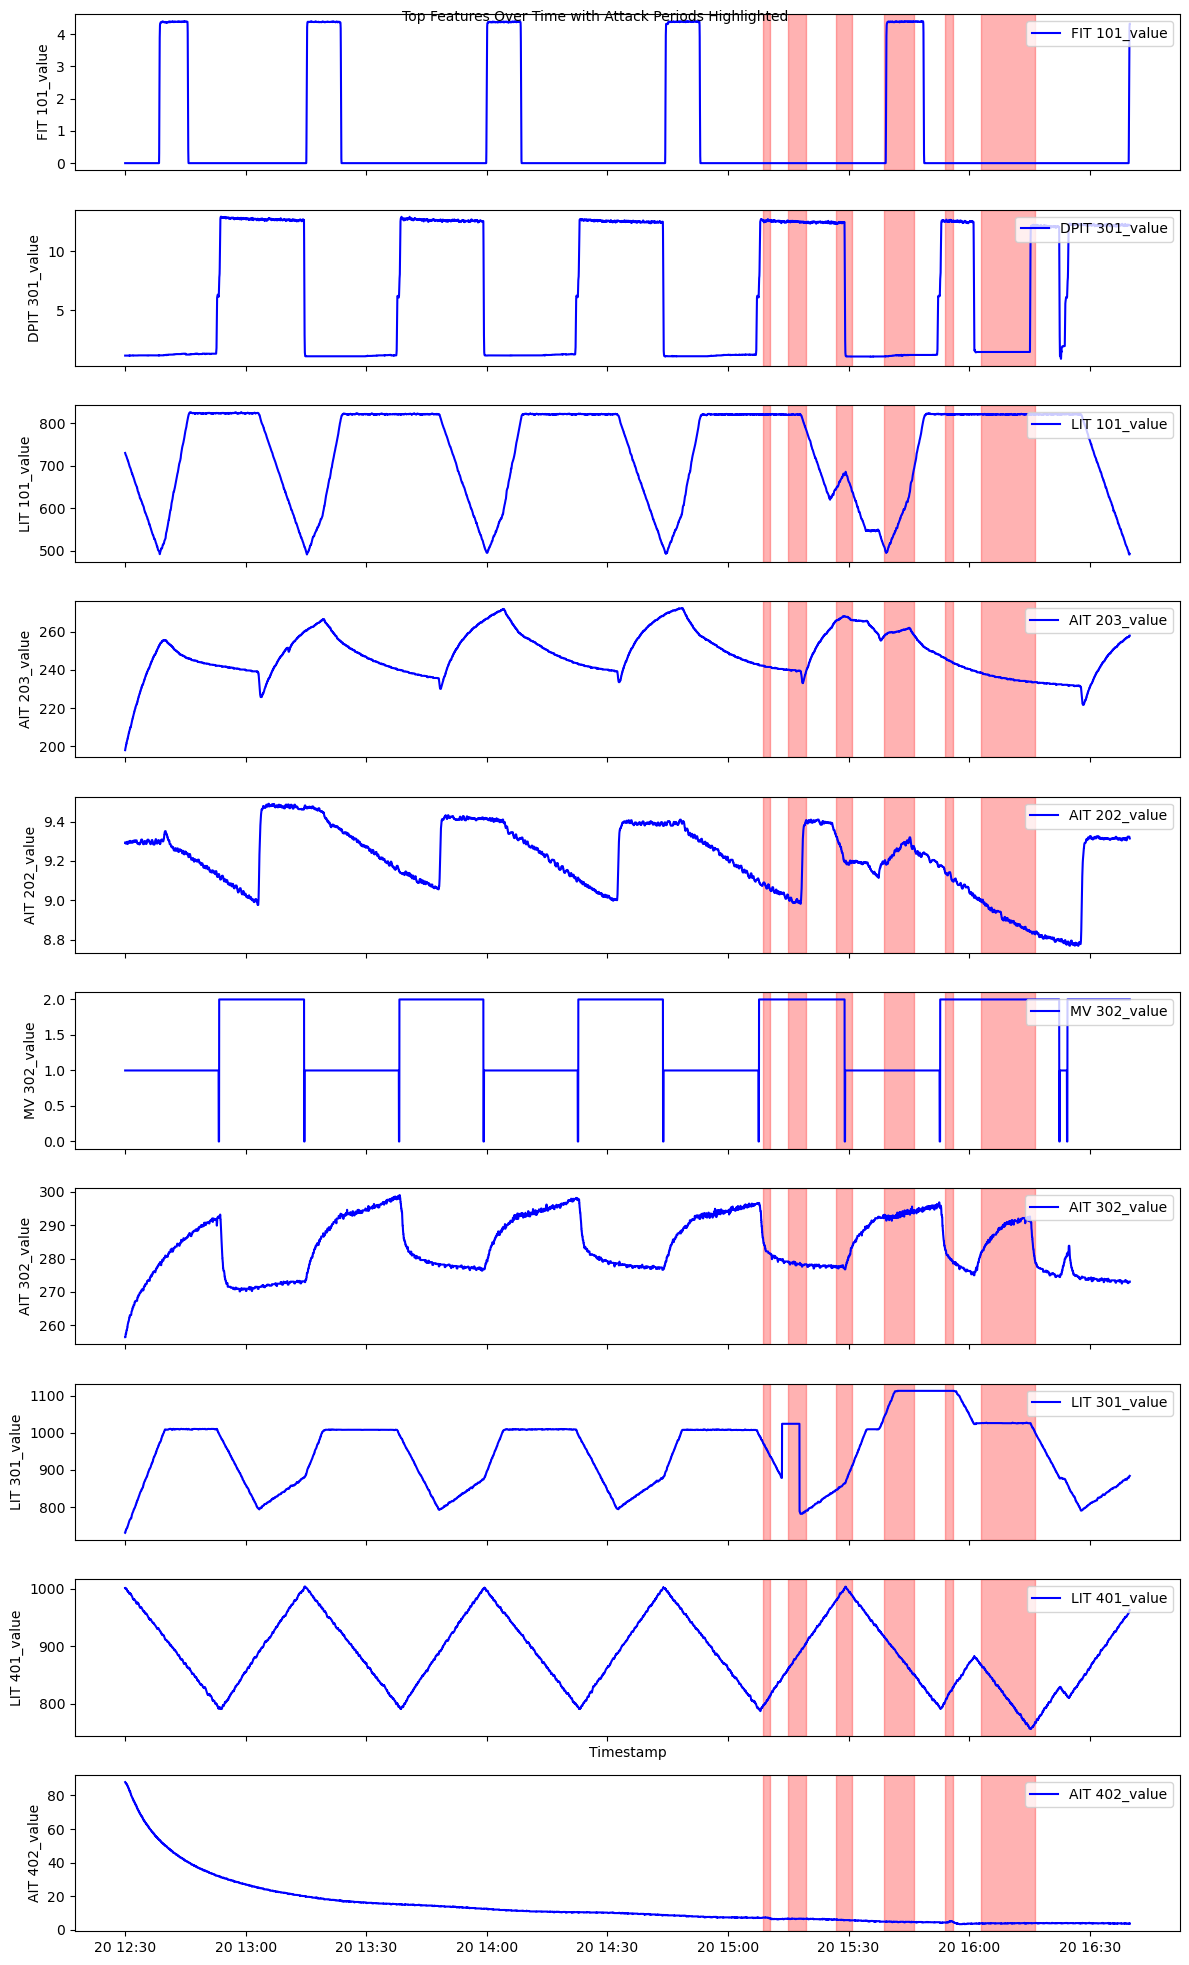

In [38]:
top_features = [
    "FIT 101_value", "DPIT 301_value", "LIT 101_value", "AIT 203_value",
    "AIT 202_value", "MV 302_value", "AIT 302_value", "LIT 301_value",
    "LIT 401_value", "AIT 402_value"
]

attack_periods = [
    ("2019-07-20 15:08:46", "2019-07-20 15:10:31"),
    ("2019-07-20 15:15:00", "2019-07-20 15:19:32"),
    ("2019-07-20 15:26:57", "2019-07-20 15:30:48"),
    ("2019-07-20 15:38:50", "2019-07-20 15:46:20"),
    ("2019-07-20 15:54:00", "2019-07-20 15:56:00"),
    ("2019-07-20 16:02:56", "2019-07-20 16:16:18"),
]
# These are known times when attacks happened in the SWaT dataset.


# Step 6: Ensure top features are numeric

for col in top_features:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
#  Convert values to numbers (if any bad text is present, replace with NaN).


# Step 7: Plot top features over time with attack periods highlighted

fig, axes = plt.subplots(len(top_features), 1, figsize=(12, 2 * len(top_features)), sharex=True)

for ax, feature in zip(axes, top_features):
    if feature not in df.columns:
        print(f"⚠ Feature '{feature}' not found in dataframe.")
        continue

    # Take only valid (non-missing) values
    feature_data = df[['timestamp', feature]].dropna()

    # Plot sensor/actuator value over time
    ax.plot(feature_data['timestamp'], feature_data[feature], label=feature, color='blue')

    # Shade attack periods in red
    for start, end in attack_periods:
        s = pd.to_datetime(start)
        e = pd.to_datetime(end)
        ax.axvspan(s, e, color='red', alpha=0.3)

    ax.set_ylabel(feature)
    ax.legend(loc='upper right')

# Add x-axis label to second-last subplot (just for space reasons)
axes[-2].set_xlabel("Timestamp")

# Title for the whole figure
fig.suptitle("Top Features Over Time with Attack Periods Highlighted", fontsize=10)
plt.tight_layout()
plt.show()

In [39]:
#checking the x reduced dataframe
X_reduced

,FIT 101_value,LIT 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,LS 201_value,LS 202_value,...,LSH 601_value,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value
0,0.000000,729.865800,3.0,2.0,1.0,142.527557,9.293002,198.077423,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
1,0.000000,729.434000,3.0,2.0,1.0,142.527557,9.293002,198.385025,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
2,0.000000,729.120000,3.0,2.0,1.0,142.527557,9.293002,198.436300,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
3,0.000000,728.688200,3.0,2.0,1.0,142.527557,9.289157,198.667000,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
4,0.000000,727.706900,3.0,2.0,1.0,142.527557,9.289157,198.897720,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,4.200429,491.169769,2.0,2.0,1.0,131.408615,9.319918,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14992,4.253915,491.405273,2.0,2.0,1.0,131.408615,9.317354,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14993,4.303558,492.308100,2.0,2.0,1.0,131.408615,9.317354,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14994,4.323736,492.465100,2.0,2.0,1.0,131.408615,9.316713,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0


In [40]:
#target variable column
y

0        1
1        1
2        1
3        1
4        1
        ..
14991    0
14992    0
14993    0
14994    0
14995    0
Name: logic_anomaly, Length: 14996, dtype: int64

In [41]:
#allocating to new variable
X = X_reduced
y = y  

In [42]:
X

,FIT 101_value,LIT 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,LS 201_value,LS 202_value,...,LSH 601_value,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value
0,0.000000,729.865800,3.0,2.0,1.0,142.527557,9.293002,198.077423,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
1,0.000000,729.434000,3.0,2.0,1.0,142.527557,9.293002,198.385025,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
2,0.000000,729.120000,3.0,2.0,1.0,142.527557,9.293002,198.436300,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
3,0.000000,728.688200,3.0,2.0,1.0,142.527557,9.289157,198.667000,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
4,0.000000,727.706900,3.0,2.0,1.0,142.527557,9.289157,198.897720,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14991,4.200429,491.169769,2.0,2.0,1.0,131.408615,9.319918,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14992,4.253915,491.405273,2.0,2.0,1.0,131.408615,9.317354,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14993,4.303558,492.308100,2.0,2.0,1.0,131.408615,9.317354,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
14994,4.323736,492.465100,2.0,2.0,1.0,131.408615,9.316713,257.703156,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0


In [43]:
from imblearn.over_sampling import SMOTE
#SMOTE fixes this by creating synthetic anomaly cases that look realistic, so both classes are balanced.
# Step 1: Decide how many samples we want in total

target_total = 30000             # We want to balance the dataset to 30,000 rows
target_class0 = int(target_total * 0.55)  # Around 55% will be normal (class 0)
target_class1 = target_total - target_class0  # The rest (45%) will be anomalies (class 1)

# This ensures we have a good balance between normal and anomaly cases.
# In the original dataset, anomalies are much fewer than normal operations.


# Step 2: Define SMOTE oversampling strategy

smote = SMOTE(
    sampling_strategy={0: target_class0, 1: target_class1},
    random_state=123
)

# SMOTE creates **synthetic (fake but realistic)** samples for the minority class (anomalies),
# so that both classes are balanced.


# Step 3: Apply SMOTE to resample dataset
X_res, y_res = smote.fit_resample(X, y)

# Now we have a new dataset (X_res, y_res) with balanced classes.

# Step 4: Put back into DataFrame for easier use
X_res_df = pd.DataFrame(X_res, columns=X.columns)
y_res_df = pd.Series(y_res, name="target")

# Combine features + target
final_df = pd.concat([X_res_df, y_res_df], axis=1)



# Step 5: Print before/after balance check
print("Before SMOTE:", dict(zip(*np.unique(y, return_counts=True))))
# Shows the original counts of normal vs anomaly.

print("After SMOTE :", dict(zip(*np.unique(y_res, return_counts=True))))
# Shows the balanced counts after SMOTE.

print("Final shape:", final_df.shape)
# Final dataset shape (rows × columns).

Before SMOTE: {np.int64(0): np.int64(2631), np.int64(1): np.int64(12365)}
After SMOTE : {np.int64(0): np.int64(16500), np.int64(1): np.int64(13500)}
Final shape: (30000, 63)


In [44]:
# smote = SMOTE(
#     sampling_strategy={0: target_class0, 1: target_class1},
#     random_state=123
# )

In [45]:
# X_res, y_res = smote.fit_resample(X, y)

# X_res_df = pd.DataFrame(X_res, columns=X.columns)
# y_res_df = pd.Series(y_res, name="target")

# final_df = pd.concat([X_res_df, y_res_df], axis=1)

# print("Before SMOTE:", dict(zip(*np.unique(y, return_counts=True))))
# print("After SMOTE :", dict(zip(*np.unique(y_res, return_counts=True))))
# print("Final shape:", final_df.shape)

In [46]:
# Shuffle the dataset after SMOTE

final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Why?
# - SMOTE creates synthetic samples in order (at the end).
# - If we don’t shuffle, the dataset will have all original samples first
#   and all synthetic samples later → this can bias training.
# - Shuffling mixes them randomly for fair training.

In [47]:
# Split features and target
X = final_df.drop('target', axis=1)   # All columns except target = input features
y = final_df['target']                # Target column (0 = normal, 1 = anomaly)

# Now X contains only sensor/actuator features,
# and y contains the label we want to predict.

In [48]:
X

,FIT 101_value,LIT 101_value,P1_STATE_value,P101 Status_value,P102 Status_value,AIT 201_value,AIT 202_value,AIT 203_value,LS 201_value,LS 202_value,...,LSH 601_value,LSH 602_value,LSH 603_value,LSL 601_value,LSL 602_value,LSL 603_value,P6 STATE_value,P601 Status_value,P602 Status_value,P603 Status_value
0,0.000000,676.168000,2.0,2.0,1.0,144.161758,9.474045,246.424000,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
1,4.384058,510.148608,2.0,2.0,1.0,118.614066,9.209796,259.523200,0,0,...,0,1,0,0,0,1,2.0,1.0,1.0,1.0
2,4.375300,666.715013,2.0,1.0,1.0,143.681100,9.337221,267.084710,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
3,4.378747,677.877956,2.0,1.0,1.0,143.841324,9.330812,265.768269,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
4,0.000000,513.661600,2.0,2.0,1.0,144.097672,9.465393,259.753900,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.000000,821.362748,2.0,1.0,1.0,143.969500,9.123790,244.293587,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
29996,0.724146,497.214700,2.0,2.0,1.0,143.809280,9.412844,266.777740,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
29997,4.389713,748.628600,3.0,1.0,1.0,143.168411,9.245258,247.551910,0,0,...,1,1,0,0,0,1,2.0,1.0,1.0,1.0
29998,4.377070,578.306496,2.0,2.0,1.0,124.957640,9.269224,260.369141,0,0,...,0,1,0,0,0,1,2.0,1.0,1.0,1.0


In [49]:
y

0        1
1        0
2        0
3        0
4        1
        ..
29995    1
29996    0
29997    0
29998    0
29999    0
Name: target, Length: 30000, dtype: int64

In [50]:
# Step 1: Get feature importance from the trained Random Forest
importances = pd.Series(model.feature_importances_, index=X.columns)
#  Each feature gets a score between 0 and 1 indicating
#  how much it contributed to the model’s predictions.

# Step 2: Select top 10 most important features
top20_features = importances.sort_values(ascending=False).head(10).index
# Sort features by importance (highest first) and pick the top 10.
# These are the features that matter most for detecting anomalies.

In [51]:
top20_features

Index(['FIT 101_value', 'DPIT 301_value', 'LIT 101_value', 'AIT 203_value',
       'AIT 202_value', 'MV 302_value', 'AIT 302_value', 'LIT 301_value',
       'LIT 401_value', 'AIT 402_value'],
      dtype='object')

In [52]:
X_selected = X[top20_features]  

In [53]:
X_selected

,FIT 101_value,DPIT 301_value,LIT 101_value,AIT 203_value,AIT 202_value,MV 302_value,AIT 302_value,LIT 301_value,LIT 401_value,AIT 402_value
0,0.000000,12.632051,676.168000,246.424000,9.474045,2.0,272.463000,834.040955,943.142761,22.430145
1,4.384058,1.149241,510.148608,259.523200,9.209796,1.0,292.524711,1073.797099,904.752018,4.896181
2,4.375300,1.200461,666.715013,267.084710,9.337221,1.0,290.697235,1008.074890,947.947742,11.663676
3,4.378747,1.136436,677.877956,265.768269,9.330812,1.0,290.569183,1007.353880,946.465476,8.177390
4,0.000000,12.609642,513.661600,259.753900,9.465393,2.0,273.180100,878.901245,999.666748,20.097410
...,...,...,...,...,...,...,...,...,...,...
29995,0.000000,1.274089,821.362748,244.293587,9.123790,1.0,295.614319,1007.554200,815.512813,7.075109
29996,0.724146,1.197260,497.214700,266.777740,9.412844,1.0,279.480133,893.440800,996.436800,12.637785
29997,4.389713,1.334913,748.628600,247.551910,9.245258,1.0,285.472800,1009.436710,875.121765,42.322483
29998,4.377070,1.238032,578.306496,260.369141,9.269224,1.0,292.570490,1112.655400,879.884171,4.768008


In [54]:
final_df=pd.concat([X_selected,y],axis=1)

In [55]:
final_df

,FIT 101_value,DPIT 301_value,LIT 101_value,AIT 203_value,AIT 202_value,MV 302_value,AIT 302_value,LIT 301_value,LIT 401_value,AIT 402_value,target
0,0.000000,12.632051,676.168000,246.424000,9.474045,2.0,272.463000,834.040955,943.142761,22.430145,1
1,4.384058,1.149241,510.148608,259.523200,9.209796,1.0,292.524711,1073.797099,904.752018,4.896181,0
2,4.375300,1.200461,666.715013,267.084710,9.337221,1.0,290.697235,1008.074890,947.947742,11.663676,0
3,4.378747,1.136436,677.877956,265.768269,9.330812,1.0,290.569183,1007.353880,946.465476,8.177390,0
4,0.000000,12.609642,513.661600,259.753900,9.465393,2.0,273.180100,878.901245,999.666748,20.097410,1
...,...,...,...,...,...,...,...,...,...,...,...
29995,0.000000,1.274089,821.362748,244.293587,9.123790,1.0,295.614319,1007.554200,815.512813,7.075109,1
29996,0.724146,1.197260,497.214700,266.777740,9.412844,1.0,279.480133,893.440800,996.436800,12.637785,0
29997,4.389713,1.334913,748.628600,247.551910,9.245258,1.0,285.472800,1009.436710,875.121765,42.322483,0
29998,4.377070,1.238032,578.306496,260.369141,9.269224,1.0,292.570490,1112.655400,879.884171,4.768008,0


In [56]:
from sklearn.model_selection import train_test_split

# Step 1: Split dataset into temporary (train+val) and test sets
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, y,                  # Features and target
    test_size=0.25,                 # 25% of data goes to testing
    random_state=42,                # Ensure reproducibility
    stratify=y                      # Keep the same ratio of normal/anomaly
)
# X_test / y_test will be used at the very end to evaluate model performance
#   (data the model has never seen).



# Step 2: Split temporary set into training and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,                 # Features/target from temporary set
    test_size=0.1,                  # 10% of temp set = ~8% of total
    random_state=42,                
    stratify=y_temp                 # Maintain class balance
)
#  X_train / y_train = main training data
#  X_val / y_val = validation data for tuning parameters and early checks


# Step 3: Print shapes of each set
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (20250, 10) (20250,)
Val: (2250, 10) (2250,)
Test: (7500, 10) (7500,)


In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# Step 1: Define a lightweight neural network

model = keras.Sequential([
    layers.Input(shape=(10,)),        # Input layer: 10 features (top selected features)
    layers.Dense(8, activation='relu'),  # Hidden layer: 8 neurons with ReLU activation
    layers.Dense(1, activation='sigmoid')  # Output layer: 1 neuron, sigmoid for binary classification
])
# This is a simple feedforward neural network:
# - Takes feature values as input
# - Processes through hidden neurons
# - Outputs probability of anomaly (0 = normal, 1 = anomaly)



# Step 2: Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # Adam optimizer with small learning rate
    loss='binary_crossentropy',                            # Binary classification loss
    metrics=[
        tf.keras.metrics.Recall(name="recall"),           # Focus on correctly detecting anomalies
        tf.keras.metrics.Precision(name="precision"),     # How many detected anomalies are real
        tf.keras.metrics.AUC(name="auc")                  # Overall model performance
    ]
)
# Metrics explanation:
# - Recall: Fraction of actual anomalies the model catches (very important for safety)
# - Precision: Fraction of predicted anomalies that are actually anomalies
# - AUC: Area under ROC curve, overall quality of predictions


# Step 3: Early stopping to prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_recall",       # Watch recall on validation set
    mode="max",                 # Want to maximize recall
    patience=3,                 # Stop if recall doesn’t improve for 3 epochs
    restore_best_weights=True   # Restore weights from best epoch
)
# Early stopping ensures the model doesn't train too long and overfit the training data.



# Step 4: Train the model

history = model.fit(
    X_train, y_train,           # Training data
    validation_data=(X_val, y_val),  # Validation data to monitor performance
    epochs=30,                  # Maximum number of passes over the dataset
    batch_size=16,              # Number of samples per gradient update
    callbacks=[early_stop]      # Stop early if recall stops improving
)
# The model will learn patterns in features to predict anomalies (logic_anomaly)
# Training stops early if validation recall stops improving

Epoch 1/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - auc: 0.6922 - loss: 13.8853 - precision: 0.6401 - recall: 0.6611 - val_auc: 0.9533 - val_loss: 0.4044 - val_precision: 0.8923 - val_recall: 0.8923
Epoch 2/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9607 - loss: 0.3258 - precision: 0.9065 - recall: 0.8976 - val_auc: 0.9817 - val_loss: 0.1751 - val_precision: 0.9369 - val_recall: 0.9684
Epoch 3/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9850 - loss: 0.1585 - precision: 0.9513 - recall: 0.9424 - val_auc: 0.9912 - val_loss: 0.0919 - val_precision: 0.9713 - val_recall: 0.9684
Epoch 4/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9914 - loss: 0.1010 - precision: 0.9663 - recall: 0.9700 - val_auc: 0.9917 - val_loss: 0.0739 - val_precision: 0.9620 - val_recall: 1.0000
Epoch 5/30
1266/1266 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - auc: 0.9917 - loss: 0.0971 - precision: 0.9666 - recall: 0.9734 - val_auc: 0.9930 - val_loss: 0.0640 - val_precision: 0.9629 - val_reca

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Step 1: Make predictions on the validation set

y_val_pred = (model.predict(X_val) > 0.5).astype("int32")
# model.predict gives probabilities (0 to 1)
# We convert probabilities > 0.5 to 1 (anomaly), else 0 (normal)


# Step 2: Calculate metrics for validation set

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred, zero_division=0)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall: {val_recall:.4f}")
# Accuracy = overall fraction of correct predictions
# Precision = fraction of predicted anomalies that are actually anomalies
# Recall = fraction of actual anomalies the model successfully detected
# We care most about recall in anomaly detection


# Step 3: Make predictions on the test set

y_test_pred = (model.predict(X_test) > 0.5).astype("int32")

# Step 4: Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
# These metrics tell you how well the model will perform on completely unseen data
# Recall remains the most important metric for catching anomalies 


71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Validation Accuracy: 0.9822
Validation Precision: 0.9620
Validation Recall: 1.0000
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Test Accuracy: 0.9825
Test Precision: 0.9632
Test Recall: 0.9994


In [60]:
# ================================
# Incremental LSTM for Logical Anomaly Detection
# ================================

import os
import numpy as np
import pandas as pd
import psutil
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------
# Config
# ----------------
WINDOW = 10
STEP = 1
TARGET_COL = "target"
BATCH_SIZE = 64
EPOCHS_PER_BATCH = 1
CHUNK_SIZE = 1000

# ----------------
# Features
# ----------------
FEATURES = [c for c in final_df.columns if c != TARGET_COL]

# ----------------
# Sequence builder
# ----------------
def build_sequences(final_df, features, target_col=TARGET_COL, window=WINDOW, step=STEP):
    X = final_df[features].values
    y = final_df[target_col].values
    X_seq, y_seq = [], []
    for i in range(0, len(X) - window + 1, step):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window-1])
    return np.array(X_seq), np.array(y_seq)

# ----------------
# Scale data
# ----------------
scaler = StandardScaler().fit(final_df[FEATURES])
final_df_scaled = final_df.copy()
final_df_scaled[FEATURES] = scaler.transform(final_df[FEATURES])

# ----------------
# Split into chunks
# ----------------
chunks = [final_df_scaled.iloc[i:i+CHUNK_SIZE] for i in range(0, len(final_df_scaled), CHUNK_SIZE)]

# ----------------
# Model
# ----------------
model = keras.Sequential([
    layers.Input(shape=(WINDOW, len(FEATURES))),
    layers.LSTM(16),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

# ----------------
# CPU / Memory usage helper
# ----------------
PROC = psutil.Process(os.getpid())

def get_usage():
    mem_bytes = PROC.memory_info().rss
    mem_mb = round(mem_bytes / 1024 / 1024, 2)
    cpu = psutil.cpu_percent(interval=0.5)
    sys_mem = psutil.virtual_memory().percent
    return {"CPU%": cpu, "Proc_Memory_MB": mem_mb, "System_Mem%": sys_mem}

# ----------------
# Incremental training with before/after resource usage
# ----------------
for i, chunk_df in enumerate(chunks):
    X_chunk, y_chunk = build_sequences(chunk_df, FEATURES, TARGET_COL, WINDOW, STEP)
    print(f"\n--- Training on chunk {i+1}/{len(chunks)} | Shape: {X_chunk.shape} ---")

    print("Usage (before fit):", get_usage())

    model.fit(X_chunk, y_chunk, epochs=EPOCHS_PER_BATCH, batch_size=BATCH_SIZE, verbose=1)

    print("Usage (after fit):", get_usage())

    y_prob = model.predict(X_chunk).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_chunk, y_pred),
        "precision": precision_score(y_chunk, y_pred, zero_division=0),
        "recall": recall_score(y_chunk, y_pred, zero_division=0),
        "f1": f1_score(y_chunk, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_chunk, y_prob)
    }
    print("Chunk metrics:", metrics)

# ----------------
# Final evaluation (last 20%)
# ----------------
test_size = len(final_df_scaled)
test_df_scaled = final_df_scaled.iloc[-test_size:]
X_test, y_test = build_sequences(test_df_scaled, FEATURES, TARGET_COL, WINDOW, STEP)

print("\n=== Usage before final test ===")
print(get_usage())

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("=== Usage after final inference ===")
print(get_usage())

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_prob)
}
print("\n=== Final Test Metrics ===")
print(final_metrics)





--- Training on chunk 1/30 | Shape: (991, 10, 10) ---
Usage (before fit): {'CPU%': 20.0, 'Proc_Memory_MB': 729.02, 'System_Mem%': 82.7}
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4753 - auc: 0.4813 - loss: 0.6981 - precision: 0.4404 - recall: 0.5553
Usage (after fit): {'CPU%': 7.0, 'Proc_Memory_MB': 766.05, 'System_Mem%': 83.0}
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step  
Chunk metrics: {'accuracy': 0.6589303733602422, 'precision': 0.6432160804020101, 'recall': 0.5663716814159292, 'f1': 0.6023529411764705, 'roc_auc': np.float64(0.6891326120150393)}

--- Training on chunk 2/30 | Shape: (991, 10, 10) ---
Usage (before fit): {'CPU%': 13.0, 'Proc_Memory_MB': 766.7, 'System_Mem%': 83.2}
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7336 - auc: 0.7738 - loss: 0.6505 - precision: 0.7649 - recall: 0.5814
Usage (after fit): {'CPU%': 15.8, 'Proc_Memory_MB': 766.7, 'System_Mem%': 83.4}
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Chunk metrics: {'accuracy': 0.7578203834510595, 'precis

In [ ]:
# # Validation predictions
# y_val_prob = model.predict(X_val).ravel()
# y_val_pred = (y_val_prob >= 0.5).astype(int)

# print("Validation:", {
#     "acc":  accuracy_score(y_val, y_val_pred),
#     "prec": precision_score(y_val, y_val_pred, zero_division=0),
#     "rec":  recall_score(y_val, y_val_pred, zero_division=0),
#     "f1":   f1_score(y_val, y_val_pred, zero_division=0),
#     "roc_auc": roc_auc_score(y_val, y_val_prob)
# })

# # Test predictions
# y_test_prob = model.predict(X_test).ravel()
# y_test_pred = (y_test_prob >= 0.5).astype(int)

# print("Test:", {
#     "acc":  accuracy_score(y_test, y_test_pred),
#     "prec": precision_score(y_test, y_test_pred, zero_division=0),
#     "rec":  recall_score(y_test, y_test_pred, zero_division=0),
#     "f1":   f1_score(y_test, y_test_pred, zero_division=0),
#     "roc_auc": roc_auc_score(y_test, y_test_prob)
# })

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_prob, dataset_name="Dataset"):
    y_pred = (y_prob >= 0.5).astype(int)  
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

    plt.figure(figsize=(5,5))
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

# Use final test set
y_test_prob = model.predict(X_test).ravel()
plot_confusion(y_test, y_test_prob, dataset_name="Test")

In [ ]:
for i, chunk_df in enumerate(chunks):
    val_split = int(0.2 * len(chunk_df))
    train_chunk_df = chunk_df.iloc[val_split:]
    val_chunk_df = chunk_df.iloc[:val_split]

    X_train_chunk, y_train_chunk = build_sequences(train_chunk_df, FEATURES, TARGET_COL, WINDOW, STEP)
    X_val_chunk, y_val_chunk = build_sequences(val_chunk_df, FEATURES, TARGET_COL, WINDOW, STEP)

    # train model on train_chunk
    model.fit(X_train_chunk, y_train_chunk, epochs=EPOCHS_PER_BATCH, batch_size=BATCH_SIZE, verbose=1)

    # plot confusion for this chunk's validation
    y_val_prob = model.predict(X_val_chunk).ravel()
    plot_confusion(y_val_chunk, y_val_prob, dataset_name=f"Chunk {i+1} Validation")

In [ ]:
from sklearn.model_selection import KFold


# Scale all features to have mean 0 and std 1 using the previously fitted scaler.
# Ensures the LSTM receives consistent, normalized input across all folds
final_df_scaled = final_df.copy()
final_df_scaled[FEATURES] = scaler.transform(final_df[FEATURES])

# Build sequences properly:
# Convert the full dataset into overlapping sequences of length WINDOW for LSTM input.
# Each sequence has WINDOW time steps and multiple features.
# Label for each sequence = last time step’s target (y_full).


X_full_seq, y_full = build_sequences(
    final_df_scaled, FEATURES, "target", WINDOW, STEP
)

# Split the dataset into 6 folds.
# shuffle=True → randomizes data before splitting to prevent bias.
# random_state=42 → ensures reproducibility

kf = KFold(n_splits=6, shuffle=True, random_state=42)

results = []
fold = 1

# Loop over each fold:
# train_index → indices of sequences for training
# test_index → indices of sequences for testing
# Ensures every sequence gets to be in test set exactly once.
for train_index, test_index in kf.split(X_full_seq):
    print(f"\n--- Fold {fold} ---")
    X_train, X_test = X_full_seq[train_index], X_full_seq[test_index]
    y_train, y_test = y_full[train_index], y_full[test_index]

    # Split further into validation set
    val_split = int(0.2 * len(X_train))
    X_val, y_val = X_train[:val_split], y_train[:val_split]
    X_train, y_train = X_train[val_split:], y_train[val_split:]

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1], X_train.shape[2])),
        layers.LSTM(16),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.AUC(name="auc")]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_recall", mode="max", patience=5, restore_best_weights=True
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=0
    )

    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    fold_result = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    print(f"Fold {fold} results:", fold_result)
    results.append(fold_result)
    fold += 1
    
# After all folds, compute average metrics across folds.
# Gives a robust estimate of model performance on unseen data.
avg_results = {metric: np.mean([r[metric] for r in results]) for metric in results[0]}
print("\n=== Average Cross-Validation Results ===")
print(avg_results)

In [ ]:
acc_list, recall_list, precision_list, auc_list = [], [], [], []

for i, chunk_df in enumerate(chunks):
    X_chunk, y_chunk = build_sequences(chunk_df, FEATURES, TARGET_COL, WINDOW, STEP)
    model.fit(X_chunk, y_chunk, epochs=EPOCHS_PER_BATCH, batch_size=BATCH_SIZE, verbose=0)

    y_prob = model.predict(X_chunk).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc_list.append(accuracy_score(y_chunk, y_pred))
    recall_list.append(recall_score(y_chunk, y_pred, zero_division=0))
    precision_list.append(precision_score(y_chunk, y_pred, zero_division=0))
    auc_list.append(roc_auc_score(y_chunk, y_prob))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(acc_list, marker='o', label="Accuracy")
plt.plot(recall_list, marker='o', label="Recall")
plt.plot(precision_list, marker='o', label="Precision")
plt.plot(auc_list, marker='o', label="AUC")
plt.title("Incremental Training Metrics per Chunk")
plt.xlabel("Chunk Number")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#All metrics are very high (~0.98–1.0), which means the model is predicting almost perfectly for each chunk.
# Flat lines indicate consistent performance across chunks.

In [ ]:
# ===== Isolation Forest: train on normal, score anomalies =====
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

FEATURES = [c for c in final_df.columns if c != "target"]

train_df, test_df = train_test_split(final_df, test_size=0.3, stratify=final_df['target'], random_state=42)

# Fit scaler on NORMAL class only
train_normal = train_df[train_df['target'] == 0].copy()
scaler = StandardScaler().fit(train_normal[FEATURES])

X_train_normal = scaler.transform(train_normal[FEATURES])
X_test = scaler.transform(test_df[FEATURES])
y_test = test_df['target'].values

# Contamination ~ expected anomaly rate in test set; you can set to y_test.mean() or a fixed small value
contam = max(1e-4, min(0.5, y_test.mean()))

iso = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=contam,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_normal)

# Sklearn output: 1 (inlier), -1 (outlier)
pred_raw = iso.predict(X_test)
y_pred = (pred_raw == -1).astype(int)  # map outlier -> 1 (anomaly)

# Optional: use decision_function (higher = more normal), so anomaly score = -decision
scores = -iso.decision_function(X_test)

# Evaluate (threshold already from predict). If you want to tune threshold, set on "scores".
print({
    "acc":  accuracy_score(y_test, y_pred),
    "prec": precision_score(y_test, y_pred, zero_division=0),
    "rec":  recall_score(y_test, y_pred, zero_division=0),
    "f1":   f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores)  # uses score; 1 = anomaly
})


In [ ]:
# Isolation Forest: train on normal, score anomalies 
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Features
FEATURES = [c for c in final_df.columns if c != "target"]

# First split: train (70%), temp (30%)
train_df, temp_df = train_test_split(
    final_df, test_size=0.3, stratify=final_df['target'], random_state=42
)

# Second split: temp -> validation (15%), test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['target'], random_state=42
)

# Fit scaler on NORMAL class only (from train)
train_normal = train_df[train_df['target'] == 0].copy()
scaler = StandardScaler().fit(train_normal[FEATURES])

X_train_normal = scaler.transform(train_normal[FEATURES])

X_val = scaler.transform(val_df[FEATURES])
y_val = val_df['target'].values

X_test = scaler.transform(test_df[FEATURES])
y_test = test_df['target'].values

# Contamination ~ expected anomaly rate in validation set
contam = max(1e-4, min(0.5, y_val.mean()))

iso = IsolationForest(
    n_estimators=300,
    max_samples='auto',
    contamination=contam,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_normal)

# Predictions
def evaluate(model, X, y, dataset_name=""):
    pred_raw = model.predict(X)
    y_pred = (pred_raw == -1).astype(int)  
    scores = -model.decision_function(X)

    results = {
        "acc":  accuracy_score(y, y_pred),
        "prec": precision_score(y, y_pred, zero_division=0),
        "rec":  recall_score(y, y_pred, zero_division=0),
        "f1":   f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, scores)
    }
    print(f"\n{dataset_name} results:", results)
    return results

# Evaluate on validation and test
val_results = evaluate(iso, X_val, y_val, "Validation")
test_results = evaluate(iso, X_test, y_test, "Test")

In [ ]:
# import matplotlib.pyplot as plt

# # Plot helper function
# def plot_metric(history, metric, title=None):
#     plt.plot(history.history[metric], label=f"train_{metric}")
#     plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
#     plt.title(title if title else metric)
#     plt.xlabel("Epochs")
#     plt.ylabel(metric)
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# # Plot Accuracy
# plot_metric(history, "accuracy", "Training vs Validation Accuracy")

# # Plot Recall
# plot_metric(history, "recall", "Training vs Validation Recall")

# # Plot Precision
# plot_metric(history, "precision", "Training vs Validation Precision")

# # Plot AUC
# plot_metric(history, "auc", "Training vs Validation AUC")